In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function, evaluate_expression

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem


from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, convert_weight_to_tensor
from typing import Optional
import pickle
import time
from tqdm import tqdm
import matplotlib.ticker as ticker

from data_generation.differential_equations import PoissonSetup1LeastSquares
from data_generation.probability_measure import generate_random_p

----------------------------------------
2025-12-11 16:50:31 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup1/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup1/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup1/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup1/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup1/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)

In [3]:
print(f'mesh args: {mesh_args}')
print(f'function space args: {function_space_args}')
print(f'output reduced basis args: {output_reduced_basis_args}')

mesh args: {'lower_left_x': 0.0, 'lower_left_y': 0.0, 'upper_right_x': 1.0, 'upper_right_y': 1.0, 'num_x': 128, 'num_y': 128, 'mesh_cell_type': 'triangle'}
function space args: {'p': {'family': 'DG', 'degree': 0}, 'u': {'family': 'CG', 'degree': 2}, 'sigma': {'family': 'RT', 'degree': 2}, 'w': {'family': 'CG', 'degree': 2}, 'q': {'family': 'CG', 'degree': 2}}
output reduced basis args: {'num_evals': 500, 'num_basis': 128}


In [4]:
mesh_size_list = [2**4, 2**5, 2**6, 2**7, 2**8]
order_list = [0, 1, 2]

In [5]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [6]:
analysis_reference_loss_array = np.zeros((len(order_list), len(mesh_size_list)))

In [7]:
num_samples = 1
seed = 0

In [10]:
for mesh_size in mesh_size_list:
    for order in order_list:
        print(f"mesh size: {mesh_size}, order: {order}")
        mesh_args['num_x'] = mesh_size
        mesh_args['num_y'] = mesh_size 
        function_space_args['u']['degree'] = order+1
        function_space_args['sigma']['degree'] = order+1  # this corresponds to RT(order)xCG(order+1), note that in FEniCSx: RT's degree input argument is order+1 for RT(order)
        function_space_args['w']['degree'] = order+1
        function_space_args['q']['degree'] = order+1

        poisson_least_squares = PoissonSetup1LeastSquares(mesh_args, function_space_args)
        mesh = poisson_least_squares.mesh
        Vh = poisson_least_squares.Vh

        batch_p, batch_mu = generate_random_p(Vh['p'], num_samples=num_samples, seed=seed)
        p_dof = np.zeros((num_samples, dolfinx.fem.Function(Vh['p']).x.array.shape[0]), dtype=np.float64)
        for i in range(num_samples):
            p_dof[i, :] = batch_p[i].x.array

        sigma_u_dim = dolfinx.fem.Function(poisson_least_squares.Vh['sigma_u']).x.array.shape[0]
        sigma_dim = dolfinx.fem.Function(poisson_least_squares.Vh['sigma']).x.array.shape[0]
        u_dim = dolfinx.fem.Function(poisson_least_squares.Vh['u']).x.array.shape[0]
        dtype = 'float64'

        sigma_u_dof = np.zeros((num_samples, sigma_u_dim), dtype=dtype)
        sigma_dof = np.zeros((num_samples, sigma_dim), dtype=dtype)
        u_dof = np.zeros((num_samples, u_dim), dtype=dtype)

        for i in tqdm(range(num_samples)):
            p = dolfinx.fem.Function(Vh['p'], dtype=dtype)
            p.x.array[:] = p_dof[i,:]
            sigma_u = poisson_least_squares.solve_sigma_u(p=p)
            sigma = sigma_u.sub(0).collapse()
            u = sigma_u.sub(1).collapse()
            sigma_u_dof[i,:] = sigma_u.x.array
            sigma_dof[i,:] = sigma.x.array
            u_dof[i,:] = u.x.array
        

        reference_loss_list = []
        for i in tqdm(range(num_samples)):
            p_fc = dolfinx.fem.Function(Vh['p'], dtype=dtype)  
            p_fc.x.array[:] = p_dof[i]
            weight = poisson_least_squares.compute_weight(p_fc)
            weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])

            y = sigma_u_dof[i]
            y = torch.tensor(y, dtype=torch_dtype['float64'])
            reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
            print(f'reference loss: {reference_loss.item()}')
            reference_loss_list.append(reference_loss.item())

        analysis_reference_loss_array[order_list.index(order), mesh_size_list.index(mesh_size)] = np.mean(reference_loss_list)

mesh size: 16, order: 0


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 11.64it/s]


reference loss: 0.04145183663556473
mesh size: 16, order: 1


100%|██████████| 1/1 [00:00<00:00, 15.18it/s]


...

reference loss: 0.0004763066342312605
mesh size: 256, order: 1



100%|██████████| 1/1 [00:05<00:00,  5.55s/it]

reference loss: 3.155482603811599e-05
mesh size: 256, order: 2



100%|██████████| 1/1 [00:20<00:00, 20.26s/it]

reference loss: 9.880249995264379e-06


In [11]:
# x = mesh.geometry.x[:, 0]
# y = mesh.geometry.x[:, 1]

# plt.tricontourf(x, y, evaluate_expression(mesh, p, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
# plt.colorbar()
# plt.show()

In [12]:
np.savetxt(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.txt"), analysis_reference_loss_array)

In [8]:
analysis_reference_loss_array = np.loadtxt(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.txt"))

In [9]:
reference_loss = np.zeros((len(order_list), len(mesh_size_list)))
inverse_mesh_size_list = [1/mesh_size for mesh_size in mesh_size_list]

In [10]:
for i, order in enumerate(order_list):
    for j in range(len(mesh_size_list)):
        reference_loss[i, j] = inverse_mesh_size_list[j]**(2*(order+1))

In [11]:
temp = np.zeros((1, len(mesh_size_list)))
for j in range(len(mesh_size_list)):
    temp[0, j] = inverse_mesh_size_list[j]**(1.5)
temp_multiplier = analysis_reference_loss_array[1, 0] / temp[0, 0]

In [12]:
multiplier = analysis_reference_loss_array[:, 0] / reference_loss[:, 0]

In [13]:
multiplier

array([1.06116702e+01, 2.85167154e+02, 1.78647926e+04])

In [14]:
markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', '*', 'h']  # add more if needed

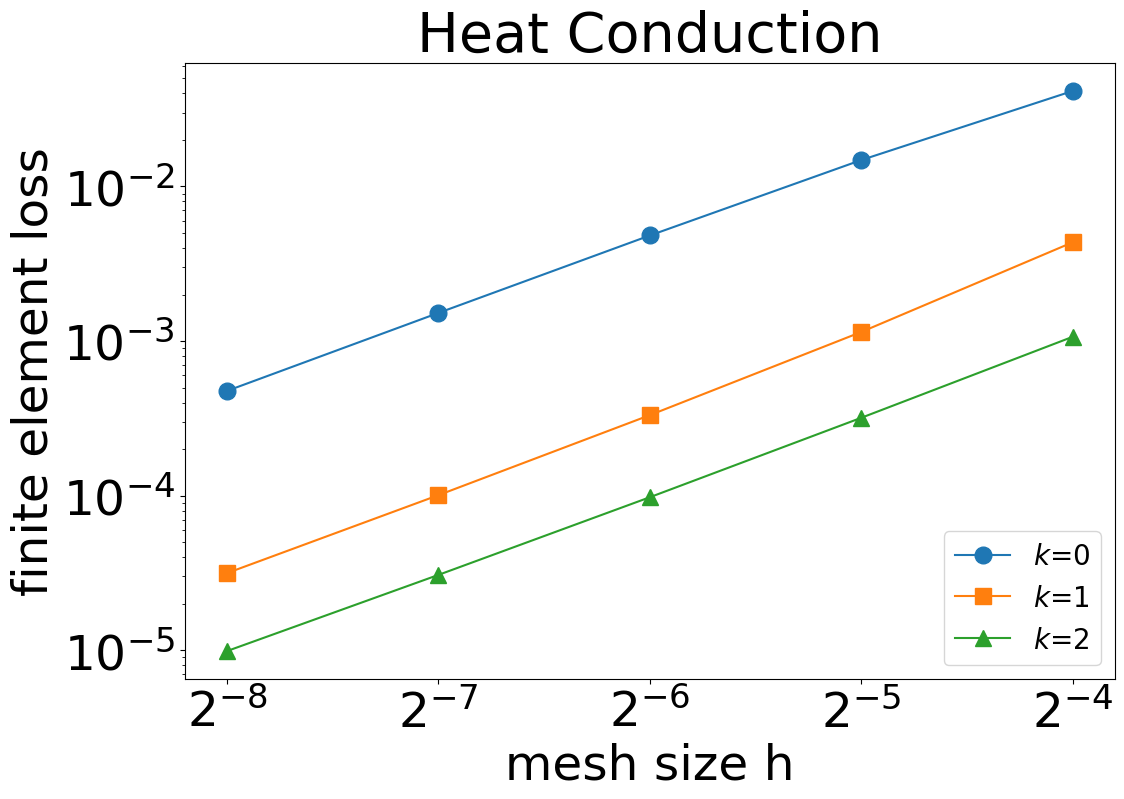

In [19]:
inverse_mesh_size_list = [1/mesh_size for mesh_size in mesh_size_list]

plt.figure(figsize=(12,8))
for i, order in enumerate(order_list):
    marker = markers[i % len(markers)]
    color = plt.cm.tab10(i % 10)  # or plt.gca()._get_lines.get_next_color()
    plt.loglog(inverse_mesh_size_list, analysis_reference_loss_array[i], marker=marker, markersize=12, label=rf'$k$={order}', color=color)

plt.yscale('log', base=10)
plt.xscale('log', base=2)
plt.xlabel('mesh size h', fontsize=35)
plt.ylabel('finite element loss', fontsize=35)
plt.tick_params(axis='both', which='major', labelsize=35)
plt.title('Heat Conduction', fontsize=40)
plt.legend(fontsize=20, loc='lower right')
plt.savefig(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.png"), dpi=300, bbox_inches='tight')
plt.show()

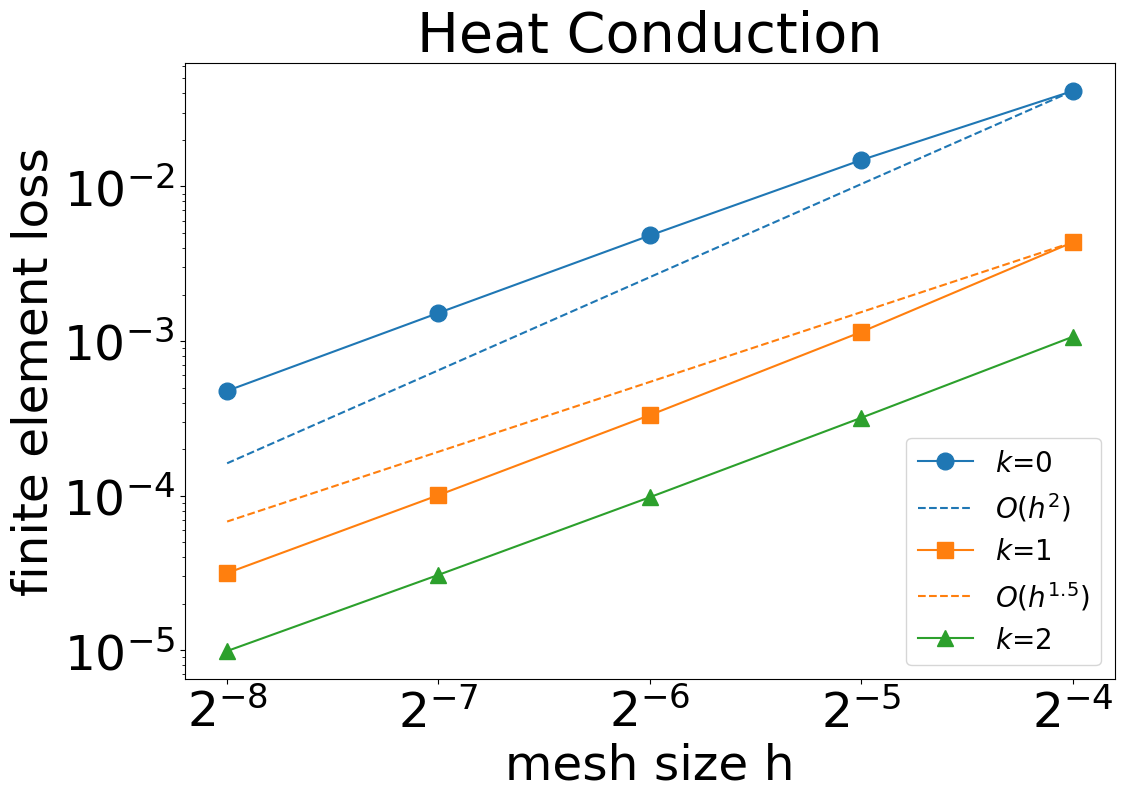

In [20]:
inverse_mesh_size_list = [1/mesh_size for mesh_size in mesh_size_list]

plt.figure(figsize=(12,8))
for i, order in enumerate(order_list):
    marker = markers[i % len(markers)]
    color = plt.cm.tab10(i % 10)  # or plt.gca()._get_lines.get_next_color()
    plt.loglog(inverse_mesh_size_list, analysis_reference_loss_array[i], marker=marker, markersize=12, label=rf'$k$={order}', color=color)
    if i == 0:
        plt.loglog(inverse_mesh_size_list, multiplier[i] * reference_loss[i], linestyle='--', label=rf'$O(h^{{{2*(order+1)}}})$', color=color)
    elif i == 1:
        plt.loglog(inverse_mesh_size_list, temp_multiplier * temp[0], linestyle='--', label=r'$O(h^{{1.5}})$', color=color)

plt.yscale('log', base=10)
plt.xscale('log', base=2)
plt.xlabel('mesh size h', fontsize=35)
plt.ylabel('finite element loss', fontsize=35)
plt.tick_params(axis='both', which='major', labelsize=35)
plt.legend(fontsize=20, loc='lower right')
plt.title('Heat Conduction', fontsize=40)
plt.savefig(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}_with_dash_lines.png"), dpi=300, bbox_inches='tight')
plt.show()